# Sequence Modelling With RNNs

### What are sequences?

**Sequential data** has a **fixed, meaningful order**. Rearranging elements destroys meaning.

RNNs are specially designed to work with sequential data, i.e. **data where there is a natural notion of a 'sequence' such as text (sequences of words, sentences etc.), videos (sequences of images), speech etc**.

Even in computer vision, RNNs are being used in tandem with CNNs in applications such as image and video processing.

````
Key Property: Order Matters!
Non-sequential → Independent examples (images, tabular data)
Sequential    → Order-dependent (text, video, audio)
````

**Text (Word Sequences)**
```
Original: "The cat sat on the mat"
Meaning:  Perfect sentence

Shuffled: "mat cat the on sat the"
Meaning:  Nonsense!
```
**Why order matters**: Grammar, context, word relationships.

**Video (Frame Sequences)**
```
Original: [Frame1 → Frame2 → Frame3] = Person walking
Meaning:  Smooth motion

Shuffled: [Frame3 → Frame1 → Frame2]
Meaning:  Jerky teleportation!
```
**Why order matters**: Temporal continuity, motion.

**Music (Note Sequences)**
```
Original: C-D-E-F-G = Happy melody
Meaning:  Pleasant tune

Shuffled: G-C-F-D-E  
Meaning:  Discordant noise!
```
**Why order matters**: Melody, harmony, rhythm.

**Time Series (Stock Prices)**
```
Original: [₹100 → ₹105 → ₹102] = Normal fluctuation
Meaning:  Predictable pattern

Shuffled: [₹102 → ₹100 → ₹105]
Meaning:  Breaks temporal causality!
```

**Sequential vs Non-Sequential Data**

| Data Type       | Order Matters? | Example Shuffle Effect          |
|-----------------|----------------|-------------------------------|
| **Images**      | No          | Still a cat!              |
| **Tabular**     | No          | Rows independent             |
| **Text**        | YES         | "Cat the sat" → Nonsense!    |
| **Video**       | YES         | Jerky motion → Unnatural!    |
| **Audio**       | YES         | Melody destroyed!            |

## Introduction to RNN

- http://karpathy.github.io/2015/05/21/rnn-effectiveness/

Recurrent Neural Networks (RNNs) are neural architectures tailored for **sequential data**, where order matters, such as text, audio, and video. They maintain a notion of **context over time**, making them especially effective for modeling sequences in natural language, speech, and time series.  

RNNs have been particularly transformative in **natural language processing**, powering applications like machine translation, sentiment analysis, question answering, speech recognition, summarization, text generation, conversational agents, and handwriting analysis. In **computer vision**, they are often combined with CNNs to handle sequence-like data such as image captions and video understanding.



Recurrent Neural Networks (RNNs), a family of neural architectures designed to handle **sequential data** such as text, time series, or audio.
- Unlike the feedforward networks studied earlier, which pass information **strictly from left to right in one pass**, RNNs incorporate **feedback connections over time**, allowing **information from previous steps to influence the current computation**.

**What key assumption of traditional (feedforward) neural networks is relaxed in recurrent neural networks (RNNs)?**

- Traditionally neural networks usually assume that inputs are **independent of one another**, processing each example in isolation with no notion of past or future context.
  - **Independently and identically distributed (IID) data:** Each data point is **sampled independently** of any other data point. Each of the data point is **sampled from same distribution** of data
- Traditional neural networks process each input independently, which is **unlike biological neural networks that maintain state and context over time**.
- **RNNs relax this independence assumption by introducing recurrent connections** that conceptually `loop back` with a time delay of one step, so the network has a notion of **memory** across a sequence of inputs, so it can model dependencies across a sequence of inputs.
  - The individual sequences are assumed to be independently and identically distributed (I.I.D.), though the entities within a sequence may have a dependence on each other.

When reading a sentence, our **internal mental representation** evolves **word by word**:

```
Step 1: "I" → Mental state: [person speaking]
Step 2: "like" → Mental state: [person + positive feeling → expecting object]  
Step 3: "deep" → Mental state: [person likes deep + expecting modifier]
Step 4: "learning" → Mental state: [person likes deep learning! Complete]
```

**Key Observation**: Each new word **modifies the current understanding** incrementally.

At each word, the brain updates based on:

```
1. **Current Representation** (what I already understand)
   - Previous words' context/memory
   
2. **New Information** (current word)
   - Fresh input added on top
   
New Mental State = f(Current State + New Word)
```

**Example Evolution**:
```
"I"           → State: [speaker]
"I like"      → State: [speaker + POSITIVE + OBJECT?]
"I like deep" → State: [speaker likes DEEP OBJECT]
"I like deep learning" → State: [speaker likes DEEP LEARNING! 🎓]
```

**RNN = Computational Model of This Process**

```
Human Brain: Mental state evolves word-by-word
RNN:         Hidden state h_t evolves timestep-by-timestep

h_t = σ(W_h * h_{t-1} + W_x * x_t + b)
     ↑↑              ↑↑
   Current     Previous    New
  Context       State      Word
```

**Exact Match**:
```
1. h_{t-1} = "Current mental representation"
2. x_t     = "New word being read"
3. h_t     = "Updated understanding"
```

```
Human Reading:                RNN Processing:
"I like deep learning"

Mental: [ ] → [I] → [I like] → [I like deep] → [I like deep learning]
                                                 ↑ Final understanding

Hidden: h0 → h1 → h2 → h3 → h4  
                    ↑ Carries ALL previous context!
```

**Why RNNs Work**: They **simulate incremental human comprehension** computationally!

**Sentiment Evolution**

```
Sentence: "The movie was great but boring"

Step 1: "The movie" → h1: [movie context, neutral]
Step 2: "was great" → h2: [movie + POSITIVE, leaning good]  
Step 3: "but"       → h3: [movie good + CONTRAST, uncertainty]
Step 4: "boring"    → h4: [movie good+bad → MIXED/NEGATIVE]

Final prediction from h4: "Mixed sentiment"
```

**Feedforward NN** (no memory): Sees "boring" alone → Wrongly "negative"

#### What Makes RNNs Different?

In the feedforward networks, information flows in one direction. There are **no cycles**, and each input is treated as an isolated example.  
$$
x \rightarrow \text{hidden layer(s)} \rightarrow \text{output}
$$
In an RNN, the hidden layer at time step $t$ receives:
- The current input $x_t$, and  
- The **previous hidden state** $h_{t-1}$.

A simple RNN update looks like:
$$
h_t = \sigma(W_x x_t + W_h h_{t-1} + b)
$$
$$
y_t = f(W_y h_t + c)
$$
where $W_x, W_h, W_y$ are weight matrices, and $(\sigma, f)$ are nonlinearities.  

Conceptually, this means:
- At each time step, the network considers both the **current input** and an **internal memory** of what it has seen before.
- This allows it to model **temporal dependencies** and patterns that unfold over time (e.g., words in a sentence).

**Like ANNs and CNNs, RNNs are Composed Operations**

- $W^\top x + b$ is a **linear transform**: `take input vector, apply weights, add bias.`
- The recurrent part $W_h h_{t-1}$ is another linear transform applied to the **previous hidden state**.
- Nonlinear functions like $\tanh$ or $\text{ReLU}$ simply **squash** the resulting vector.
- An RNN is nothing more than **reusing the same layer over multiple time steps**, feeding its previous output back as part of its next input.

**RNNs add an additional Time Dimension**

**Key Difference**: RNNs have **two dimensions**:
1. **Depth $l$** (layers, same as feedforward)
2. **Time $t$** (sequence position, i.e. along the sequence length)

**New notation**: $h_{t}^l$ = "activation at layer $l$, time $t$"  
*(Not just "layer $l$" anymore!)*

- Feedforward: $h^l$  
- RNN:         $h_t^l$  (time-aware!, the network changes its state with time as it sees new words in a sentence, new frames in a video etc.)

**RNN State Evolution**

RNNs **change state over time** as they process sequences:
- Time t:   $h_t^l $ (current state)
- Time t+1: $h_{t+1}^l$  (updated state after new input)

**$h_{t+1}^l$ depends on TWO things**:
1. **Feedforward input**: $h_{t+1}^{l-1}$ (previous layer, **same time**)
2. **Recurrent input**: $h_t^l$ (**own previous state**, previous time)

```
h_{t+1}^l = g( h_{t+1}^{l-1}, h_t^l )
        ↑↑           ↑↑
     Layer l-1    Own previous
     (same time)   state (prev time)
```

**Recurrent relationship**: Current state depends on **previous state** → **RNN**!

## Why Use RNNs?

To model situations where the correct output depends on **context over time**, not just the current input (e.g., word sense, part-of-speech, sequence classification).

**The state of the network updates itself as it sees new elements in the sequence**

### Intuition

Consider the task: **classify a single word** (e.g., part-of-speech tagging: noun, verb, etc.).

- A basic feedforward network can **take a word embedding $x$ and output a label $\hat{y}$**. This works, but it ignores a crucial fact:  the **correct label often depends on surrounding words**, not just the word itself.

- Example: the word **“bank”**  
  - “I deposited cash at the bank” → noun, financial sense  
  - “We walked along the river bank” → noun, geographical sense  
  - “They bank the plane to the left” → verb  

- A feedforward net that only sees the current word cannot distinguish these uses. The **target label is not a function of the current input alone**; it also depends on **context** (previous and sometimes future words).

- RNNs address this by allowing the model to maintain a **hidden state** that summarizes information from **previous time steps**, so predictions at time $t$ can depend on $(x_1, \dots, x_t)$, not just $x_t$.

### Hidden Layers in ANN, CNNs to Hidden States in RNNs

- Refer: https://colah.github.io/posts/2015-08-Understanding-LSTMs/

In ANNs, CNNs hidden layers in a neural network compute **hidden representations** of the input:
- Feature tranformations $h^1 = W^{1T}x + b^1$ in ANN
- Learned features such as `eye detector` or `edge detector` for images.
- The same idea applies in NLP: a hidden layer might represent “
  - Is this word a proper noun?,
  - Is this word related to finance?, etc.
- For sequential tasks, we want the hidden representation at time $t$ to depend on:
  - The current input $x_t$, and  
  - Everything the model has seen before $(x_1, \dots, x_{t-1})$.
- To incorporate hidden representations RNN feeding the **previous hidden representation** $h_{t-1}$ into the computation of the current hidden state $h_t$. Over time, information flows from **all past inputs** into the current hidden state through this recurrence.

### What makes them “recurrent”?


  They apply the **same transformation repeatedly**, using **previous hidden state** as part of the input. The equations define a **recurrence relation** over time.

- A common way to visualize an RNN is in two equivalent forms: **Unrolled vs Recurrent Diagram**
  - **Rolled / Compact diagram**: A single block with a **self-loop** on the hidden layer indicating `this unit feeds back into itself one step later.`
  - **Unrolled over time** (step-by-step): Each time step has its own copy of the `cell`, but **all copies share the same weights**.
  $$
  \begin{aligned}
  h_1 &= f(x_1, h_0) \\
  h_2 &= f(x_2, h_1) \\
  h_3 &= f(x_3, h_2) \\
  &\dots
  \end{aligned}
  $$

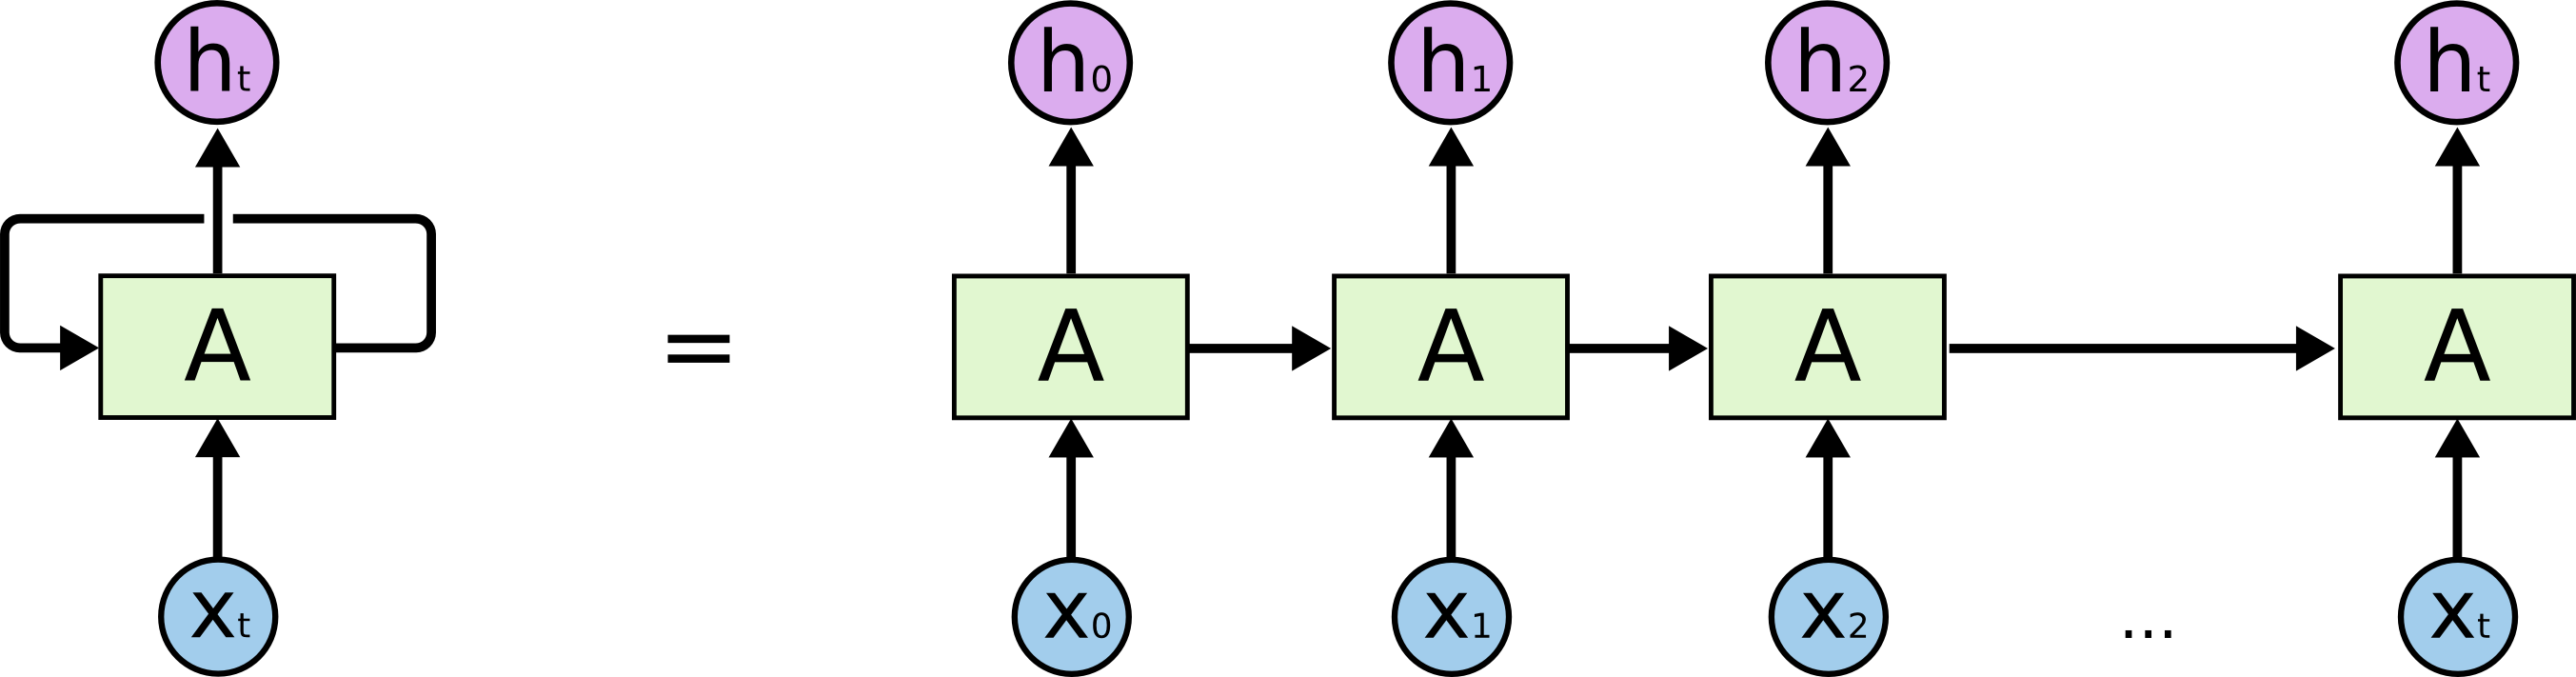

- At each time step, the hidden state is updated, **same** RNN cell is applied repeatedly along the sequence.

## How RNN Works?

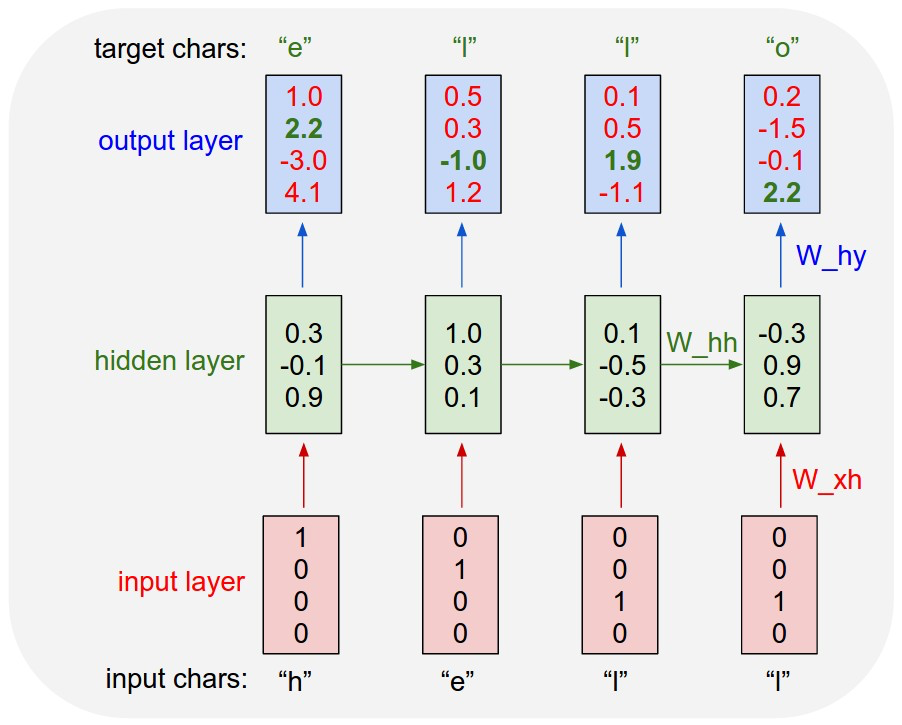

The central pattern idea in feedforward nets is:

$$
W^\top x + b
$$

which means `apply a linear transformation to the input and add a bias.` In an RNN, this pattern is reused in two places at each time step:

- One linear transform for the **previous hidden state** $h_{t-1}$.  
- One linear transform for the **current input** $x_t$.

Then they are **added and passed through a nonlinearity** (e.g., \$tanh$, ReLU) to get the new hidden state.

Let:
- $h_t \in \mathbb{R}^M$: hidden state at time $t$ (size $M$)  
- $x_t \in \mathbb{R}^D$: input at time $t$ (size $D$)  

Weights and biases:
- $W_h \in \mathbb{R}^{M \times M}$: hidden-to-hidden weights  
- $b_h \in \mathbb{R}^{M}$: bias for recurrent transform  
- $W_x \in \mathbb{R}^{D \times M}$: input-to-hidden weights  
- $b_x \in \mathbb{R}^{M}$: bias for input transform  

A single time step update:

$$
h_t = \sigma\big( W_h^\top h_{t-1} + b_h + W_x^\top x_t + b_x \big)
$$

where $\sigma$ is usually $\tanh$ or ReLU.

- **Every arrow** in the RNN diagram corresponds to a `multiply by $W$, add $b$` operation.  
- The **weights differ by arrow type**:
  - Input $\to$ hidden uses $W_x, b_x$.  
  - Hidden $\to$ hidden uses $W_h, b_h$.  
- The output of this transformation is the **new hidden state** $h_t$, sometimes called the **hidden state** or **state** for short.

This is why it’s called a **recurrent** network: the same computation is **repeated over time** and depends on its own previous state.

Like ANNs and CNNs, **tensor shapes** (shape of trainable parameter tensors) are crucial for understanding RNNs.

Let:
- Hidden size $M$: dimension of $h_t$  
- Input size $D$: dimension of $x_t$

Then:
- $W_h$ maps $\mathbb{R}^M \to \mathbb{R}^M$, so shape is $M \times M$.  
- $W_x$ maps $\mathbb{R}^D \to \mathbb{R}^M$, so shape is $D \times M$.

The convention “input size × output size” is used so that:
- Entry $w_{ij}$ corresponds to the weight from **input unit $i$** to **output unit $j$**.  
- We often write $W^\top x$ in math, but in code you typically write `x @ W` with shapes `[batch, D] @ [D, M] → [batch, M]`.

Biases:
- $b_h, b_x$ must have shape $(M,)$ since they are added to the hidden vector of size $M$.

The recurrence can be written in slightly different but equivalent forms:

1. **Single bias term**

Instead of separate $b_h$ and $b_x$, you can combine them:
$$
b = b_h + b_x
$$
$$
h_t = \sigma\big( W_h^\top h_{t-1} + W_x^\top x_t + b \big)
$$

2. **Concatenate input and hidden**

Define a combined vector:
$$
z_t = \begin{bmatrix} h_{t-1} \\ x_t \end{bmatrix} \in \mathbb{R}^{M + D}
$$

Then use a single weight matrix:
$$
W \in \mathbb{R}^{(M + D) \times M}
$$

$$
h_t = \sigma\big( W^\top z_t + b \big)
$$

This is equivalent to concatenating $W_h$ and $W_x$ horizontally into one big matrix. The shape reasoning:
- Input to this layer: size $M + D$.  
- Output (hidden state): size $M$.  
- Therefore, $W$ is $(M + D) \times M$.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import SimpleRNN, Input, Dense
from tensorflow.keras.models import Model

In [ ]:
sentences = [
    "i like deep learning",
    "i like nlp",
    "i enjoy machine learning",
    "deep learning is fun",
    "nlp is fun"
]

In [ ]:
# Tiny toy "text" dataset as integer ids
# Suppose vocab = {1:"i", 2:"like", 3:"deep", 4:"learning"}
vocab_size = 5      # 0 for padding, 1–4 are words
seq_len = 3         # sequence length
hidden_dim = 4

In [ ]:
# Dummy sequences: shape (batch, time)
X_ids = np.array([
    [1, 2, 3],
    [2, 3, 4],
    [1, 3, 4]
], dtype=np.int32)

batch_size = X_ids.shape[0]
batch_size

3

In [ ]:
# Convert to one-hot: (batch, time, vocab_size)
X = tf.one_hot(X_ids, depth=vocab_size).numpy()
print("Input X shape:", X.shape)       # (batch, time, vocab_size)

Input X shape: (3, 3, 5)


In [ ]:
# Build RNN (input_dim = vocab_size)
inputs = Input(shape=(seq_len, vocab_size))
rnn = SimpleRNN(hidden_dim, return_sequences=True, return_state=True,
                activation='tanh', use_bias=True, name="simple_rnn")
all_h, last_h = rnn(inputs)   # all_h: (batch, time, hidden_dim), last_h: (batch, hidden_dim)

# Optional output layer (not really used here)
output = Dense(1, activation='sigmoid', name="out")(last_h)
model = Model(inputs, [all_h, last_h, output])
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 3, 5)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ [(None, 3, 4), (None,  │            40 │
│                                 │ 4)]                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ out (Dense)                     │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45 (180.00 B)

 Trainable params: 45 (180.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 4. Inspect random initialized RNN weights
Wx, Wh, b = rnn.get_weights()  # Wx: (input_dim, units), Wh: (units, units), b: (units,)

print("\nRNN weight shapes:")
print("Wx (input→hidden):", Wx.shape)   # (vocab_size, hidden_dim)
print("Wh (hidden→hidden):", Wh.shape)  # (hidden_dim, hidden_dim)
print("b  (bias):", b.shape)            # (hidden_dim,)

print("\nSample Wx:\n", Wx)
print("\nSample Wh:\n", Wh)
print("\nSample b:\n", b)


RNN weight shapes:
Wx (input→hidden): (5, 4)
Wh (hidden→hidden): (4, 4)
b  (bias): (4,)

Sample Wx:
 [[ 3.6100161e-01  5.6275606e-02  1.6960388e-01  5.8682263e-02]
 [-4.4687295e-01 -7.6313150e-01  5.6385493e-01 -7.3111475e-02]
 [ 2.5618815e-01 -3.9302886e-02  2.5139093e-01  3.8177693e-01]
 [ 2.0675063e-01 -8.1106442e-01 -7.6717651e-01 -8.1527895e-01]
 [-1.8231279e-01 -7.6133013e-04  4.2223525e-01 -4.9763009e-01]]

Sample Wh:
 [[-0.39630473 -0.03961668 -0.32827163 -0.8565109 ]
 [-0.1686252   0.9008484  -0.3600547   0.17435169]
 [ 0.07526905 -0.3911265  -0.8619698   0.3136281 ]
 [ 0.8993568   0.18418182 -0.14002256 -0.3709826 ]]

Sample b:
 [0. 0. 0. 0.]


In [ ]:
# Run a forward pass to see hidden states
all_h_val, last_h_val, out_val = model.predict(X, verbose=0)

print("all_h shape:", all_h_val.shape)     # (batch, time, hidden_dim)
print("last_h shape:", last_h_val.shape)     # (batch, hidden_dim)
print("First sequence, all hidden states:\n", all_h_val[0])

all_h shape: (3, 3, 4)
last_h shape: (3, 4)
First sequence, all hidden states:
 [[-0.41932517 -0.6429178   0.5108321  -0.07298148]
 [ 0.46493918 -0.67239624  0.18815741  0.67295575]
 [ 0.63828    -0.88203436 -0.73250824 -0.908938  ]]


## Vanishing and exploding gradients

**Theoretical Power**: RNNs can learn **long-term dependencies** (e.g., word 1 affects word 8 in translation).  
**Practical Reality**: **Extremely hard to train** on long sequences due to **gradient problems**. RNNs fail on sequences > 10-20 timesteps!

```
Vanishing Gradient Timeline:
1990s: RNNs invented → Exciting theory
2000s: Vanishing gradients discovered → Practical failure
2014: LSTM/GRU popularized → RNN renaissance
2017+: Transformers replace RNNs entirely
```

#### Backpropagation Through Time (BPTT)



**Standard NN**: Errors flow **layer → layer** (right-to-left).  
**RNN**: Errors flow **layer → layer AND time → time** (backwards through sequence).

Output $y_t$ depends on: $x_t, x_{t-1}, x_{t-2}, ..., x_1$

Loss $L_t$ affects: ALL previous weights through long chain!

**Example**: 40-word sentence → **40 time steps of backprop** × **multiple layers** = **exploding computation**!

**RNN Feedforward**:
$$
h_t^l = σ(W_x h_{t}^{l-1} + W_h h_{t-1}^l + b^l)
$$

**Gradient through time**: Depends on recurrent weight
$$
∂h_t^l / ∂h_{t-1}^l = g(W_h)    
$$
$$
∂h_{t-1}^l / ∂h_{t-2}^l = g(W_h)
$$
...
$$
∂h_T^l / ∂h_1^l = [g(W_h)]^{T-1}   
$$

**The Core Problem: $(W_h)^n$**

**Long sequences** → **W_R raised to high powers** during backprop:

```
If ||W_h|| > 1:  (W_h)^n → ∞     → EXPLODING GRADIENTS
If ||W_h|| < 1:  (W_h)^n → 0     → VANISHING GRADIENTS
```

**Result**: Early time steps get **tiny/no gradients** → **Can't learn long-term dependencies**!

**Vanishing Gradients:**
- Early words forgotten
- "The cat, which was very hungry, sat..." → Can't remember "cat"
- RNNs act like **memoryless** networks

**Workaround**
- Short sequences: Limits to 5-10 words (compromise)
- LSTM/GRU: Architectural fixes (next lecture)
- Better initialization

**Exploding Gradients**
- NaN losses, training divergence
- Weights become infinite

**Workaround**
```
GRADIENT CLIPPING: Cap gradients at threshold
if ||∇|| > max_norm: ∇ = ∇ × (max_norm / ||∇||)
Simple, effective! Used in all RNN frameworks.
```

## Types of RNN

RNN architectures can be adapted to many task types by changing how sequences are mapped to outputs.

By choosing the appropriate input–output shape and loss definition, the same underlying RNN machinery can support a wide variety of sequence learning problems.

- **Many-to-one**: sequence → single output  
  - Sentence classification, sentiment scoring, video classification.
- **Many-to-many (equal length)**: sequence → sequence, aligned per time step  
  - POS tagging, frame-wise labeling.
- **Many-to-many (encoder–decoder)**: sequence → sequence, different lengths  
  - Machine translation, summarization, seq-to-seq tasks.
- **One-to-many**: single input → sequence  
  - Generative models for music, text, or other structured sequences.

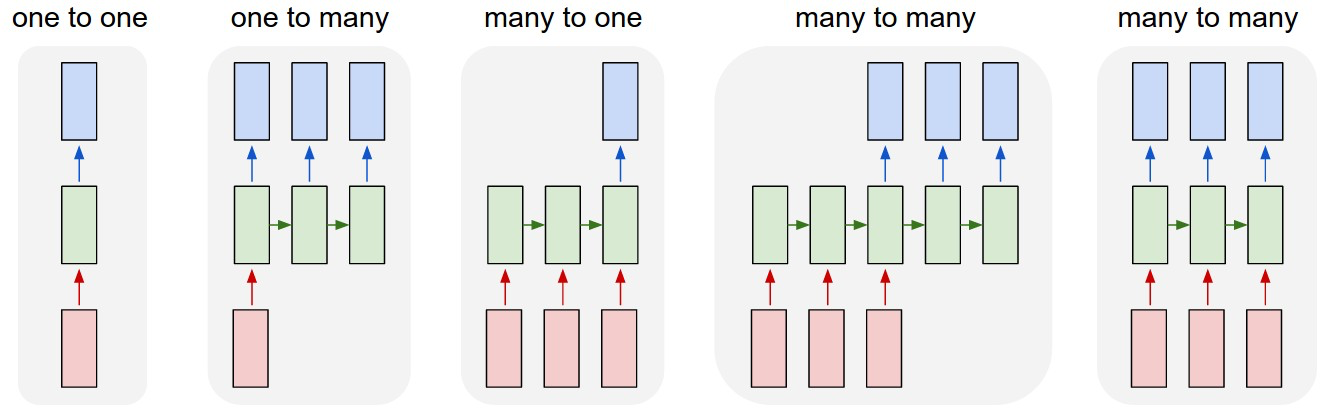

One-to-One

In [ ]:
import numpy as np

In [ ]:
# Model Building for ANN
X = np.random.randn(10,)
X.shape

(10,)

In [ ]:
from keras.layers import SimpleRNN, Dense, Input
from keras.models import Model

In [ ]:
# ANN
M, K = 64, 10
input = Input(shape = (10,))
hidden = Dense(64, activation = 'relu')(input)
output = Dense(K)(hidden)
model = Model(input, output)
model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 64)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,354 (5.29 KB)

 Trainable params: 1,354 (5.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Model Building for ANN
X = np.random.randn(10, 300)
X.shape

(10, 300)

In [ ]:
300*64 + 64*64

23296

In [ ]:
# RNN
M, K = 64, 10
input = Input(shape = (*X.shape,)) # Shape: (Batch size x 10 elements x 300D vector each)
rnn = SimpleRNN(M)(input) # Weights Wx - (300 x 64), Wh - (64 X 64) + bias - 64
output = Dense(K)(rnn) # Weights (64 x 10) + 10
model = Model(input, output)
model.summary()

Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 10, 300)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, 64)             │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,010 (93.79 KB)

 Trainable params: 24,010 (93.79 KB)

 Non-trainable params: 0 (0.00 B)

### Many-to-one RNN

In a many-to-one setup, the **input is a sequence**, but the **output is a single value** (or label). The RNN processes all time steps, and only after the **final time step** does it emit the prediction.

- Example 1: **Sentence classification**
  - Input: sequence of word vectors $(x_1, x_2, \dots, x_T)$
  - Output: single label, e.g. “grammatically correct / incorrect” or “spam / not spam”.
  - The prediction is based on the last hidden state $h_T$, which summarizes the whole sentence.

- Example 2: **Sentiment scoring**
  - Input: customer review text as a word sequence.
  - Output:
    - Regression: real-valued sentiment score in $[-1, 1]$.
    - Classification: discrete sentiment (negative / neutral / positive).

- Example 3: **Video classification**
  - Input: sequence of frame features from a video.
  - Output: a single probability (e.g. “violent content” vs “non-violent”).

For many-to-one, if the model produces a single output $y_{\text{out}}$ and the true label is $y$, a typical loss is:
$$
L = \text{cross-entropy}(y_{\text{out}}, y)
$$
Loss is computed and backpropagated **after the entire sequence has been read**.

In [ ]:
# RNN
M, K = 64, 1
input = Input(shape = (*X.shape,)) # Shape: (Batch size x 10 elements x 300D vector each)
rnn = SimpleRNN(M)(input) # Weights Wx - (300 x 64), Wh - (64 X 64) + bias - 64
output = Dense(K)(rnn) # Weights (64 x 10) + 10
model = Model(input, output)
model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 10, 300)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 64)             │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,425 (91.50 KB)

 Trainable params: 23,425 (91.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.layers import GlobalMaxPooling1D

In [ ]:
# RNN
M, K = 64, 1
input = Input(shape = (*X.shape,)) # Shape: (Batch size x 10 elements x 300D vector each)
rnn = SimpleRNN(M, return_sequences=True)(input) # Weights Wx - (300 x 64), Wh - (64 X 64) + bias - 64
pool = GlobalMaxPooling1D()(rnn)
output = Dense(K)(pool) # Weights (64 x 10) + 10
model = Model(input, output)
model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_16 (InputLayer)     │ (None, 10, 300)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_14 (SimpleRNN)       │ (None, 10, 64)         │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,425 (91.50 KB)

 Trainable params: 23,425 (91.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Stacking layers
# RNN
M, K = 64, 1
input = Input(shape = (*X.shape,)) # Shape: (Batch size x 10 elements x 300D vector each)
rnn1 = SimpleRNN(M, return_sequences=True)(input) # Weights Wx - (300 x 64), Wh - (64 X 64) + bias - 64
rnn2 = SimpleRNN(M)(rnn1) # Weights Wx - (64 x 64), Wh - (64 X 64) + bias - 64
output = Dense(K)(rnn2) # Weights (64 x 10) + 10
model = Model(input, output)
model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_17 (InputLayer)     │ (None, 10, 300)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_15 (SimpleRNN)       │ (None, 10, 64)         │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_16 (SimpleRNN)       │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,681 (123.75 KB)

 Trainable params: 31,681 (123.75 KB)

 Non-trainable params: 0 (0.00 B)

**Parameters**

In [ ]:
n_cells = 64          # Hidden units
time_steps = 10       # Sequence length
features = 32         # Features per timestep
n_classes = 5         # Output classes
n_output = n_classes  # or 1 for regression
output_activation = 'softmax'  # 'softmax'/'sigmoid'/'linear'

**Sentiment analysis, sentence classification**

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN

model = Sequential()
model.add(SimpleRNN(n_cells, input_shape=(time_steps, features)))
model.add(Dense(n_output, activation=output_activation))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,533 (25.52 KB)

 Trainable params: 6,533 (25.52 KB)

 Non-trainable params: 0 (0.00 B)

**Input**: `(batch, time_steps, features)`  
**Output**: `(batch, n_output)` ← **Single prediction after full sequence**

### Many-to-Many RNN (with equal input and output lengths)

Here both **input and output are sequences of the same length**: one output per time step.

- Example: **Part-of-speech (POS) tagging**
  - Input: sequence of words $(x_1, \dots, x_T)$.
  - Output: sequence of POS tags $(y_1, \dots, y_T)$.
  - At each time step $t$, the RNN reads $x_t$ and predicts a tag $y_t$.

General case:
- Inputs: $(x_1, \dots, x_{T_1})$
- Outputs: $(y_1, \dots, y_{T_2})$, with **$T_1 = T_2$** in this subtype.

If the model outputs $(y'_1, \dots, y'_{T_2})$, the sequence loss is:
$$
L = \sum_{i=1}^{T_2} \text{cross-entropy}(y'_i, y_i)
$$
The RNN emits an output at each time step, and the **total loss is the sum** of per-step losses, backpropagated after the full sequence.

In [ ]:
# RNN
M, K = 64, 10
input = Input(shape = (*X.shape,)) # Shape: (Batch size x 10 elements x 300D vector each)
rnn = SimpleRNN(M, return_sequences=True)(input) # Weights Wx - (300 x 64), Wh - (64 X 64) + bias - 64
output = Dense(K)(rnn) # Weights (64 x 10) + 10
model = Model(input, output)
model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_13 (InputLayer)     │ (None, 10, 300)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 10, 64)         │        23,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10, 10)         │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,010 (93.79 KB)

 Trainable params: 24,010 (93.79 KB)

 Non-trainable params: 0 (0.00 B)

**POS tagging, frame-wise classification**

In [ ]:
from keras.layers import TimeDistributed

model = Sequential()
model.add(SimpleRNN(n_cells, input_shape=(time_steps, features), return_sequences=True))
model.add(TimeDistributed(Dense(n_classes, activation=output_activation)))
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_5 (SimpleRNN)        │ (None, 10, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 10, 5)          │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,533 (25.52 KB)

 Trainable params: 6,533 (25.52 KB)

 Non-trainable params: 0 (0.00 B)

**Key**: `TimeDistributed` applies Dense **at every timestep**  
**Output**: `(batch, time_steps, n_classes)` ← **One output per input**

### Many-to-many RNN (encoder–decoder, with sequences of unequal lengths)

In many real problems, **input and output sequence lengths differ**. An important example is the **encoder–decoder architecture** used in sequence-to-sequence tasks.

- Example: **Machine translation**
  - Input: Hindi sentence $(x_1, \dots, x_{T_1})$.
  - Output: English sentence $(y_1, \dots, y_{T_2})$ with $T_2 \neq T_1$ in general.

Architecture:
1. **Encoder RNN**
   - Reads the entire input sequence.
   - Produces a final hidden state (the **encoded / context vector**) that summarizes the input.
2. **Decoder RNN**
   - Takes the context vector as its initial state.
   - Generates the output sequence one token at a time: $(y'_1, y'_2, \dots, y'_{T_2})$.

  
The decoder does **not** produce outputs while the encoder is still reading inputs. The encoder first consumes the **whole** input sequence; only then is its final state passed to the decoder, which starts generating the output sequence step by step.

Loss for a target output sequence $(y_1, \dots, y_{T_2})$ with predictions $(y'_1, \dots, y'_{T_2})$ is again:
$$
L = \sum_{i=1}^{T_2} \text{cross-entropy}(y'_i, y_i)
$$
Because there's no one-to-one alignment between input and output time steps, this architecture allows **flexible input/output lengths** and is widely used for translation, summarization, dialogue, etc.

**Machine translation, summarization**

**Flow**:
1. Encoder reads **entire input** → context vector
2. `RepeatVector` duplicates context for each output step
3. Decoder generates **output sequence**

### One-to-many RNN

In a one-to-many setup, the **input is a single entity**, and the **output is a sequence**.

- Example: **Music generation**
  - Input: a genre or style vector (e.g. “jazz”).
  - Output: a sequence of notes or chords.

- Example: **Text generation**
  - Input: a prompt or topic embedding.
  - Output: a sequence of words forming a paragraph.

- Example: **Image or landscape generation from a keyword** (in older RNN-style generative setups)
  - Input: a label or condition (e.g. “mountain”).
  - Output: a sequence describing content (or parameters) that can be rendered as an image.

Here, the input is fed (possibly just once) to initialize the hidden state, and the RNN then **iteratively generates outputs over time**. The loss again sums over time steps when training against target sequences.

**Music generation, text completion**

In [ ]:
model = Sequential()
# Single input timestep
model.add(SimpleRNN(n_cells, input_shape=(1, features), return_sequences=True))
# Generate sequence of outputs
model.add(TimeDistributed(Dense(n_classes, activation='softmax')))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_7 (SimpleRNN)        │ (None, 1, 64)          │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 1, 5)           │           325 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,533 (25.52 KB)

 Trainable params: 6,533 (25.52 KB)

 Non-trainable params: 0 (0.00 B)

**Input**: `(batch, 1, features)`  
**Output**: `(batch, output_timesteps, n_classes)`

## Bidirectional RNN (Past + Future Context)
**Better sentence understanding**

### Online vs Offline Sequence Processing

Sequence tasks fall into two broad categories:

- **Online sequence processing**  
  - The model must make predictions as data arrives.  
  - The **full sequence is not available** in advance.  
  - Example:  
    - A phone keyboard that predicts the **next word** while a user types. Only the previous words are known; future words are unknown at prediction time.

- **Offline sequence processing**  
  - The **entire sequence is available** before prediction.  
  - The model can see both past and future tokens before producing outputs.  
  - Examples:  
    - Sentiment classification: reading a full review, then outputting a single sentiment score.  
    - Classifying a complete tweet, email, or document.  
    - Tagging an entire video after all frames are available.

A **bidirectional RNN** can only be used in **offline** settings, because it needs access to the **full sequence** to process it both forward and backward.

#### Intuition

Standard RNN (unidirectional):

- Processes the sequence in **one direction**, usually left-to-right.  
- At time $$t$$, the hidden state uses information from $x_1, x_2, \dots, x_t$ only.

Bidirectional RNN:

- Runs **two RNNs**:
  - One forward over the sequence: $x_1 \to x_2 \to \dots \to x_T$.  
  - One backward over the sequence: $x_T \to x_{T-1} \to \dots \to x_1$.  
- At each position $t$, it concatenates (or otherwise combines) the forward and backward hidden states:
  - $\overrightarrow{h_t}$: context from the **past** (left side).  
  - $\overleftarrow{h_t}$: context from the **future** (right side).  
  - Combined representation: $[\,\overrightarrow{h_t}; \overleftarrow{h_t}\,]$.

This lets the model “look both ways” in the sequence, which typically improves performance on offline tasks.

**Benefits:**

- **Richer context**: Each time step sees both left and right context.  
- Often yields **better accuracy** than unidirectional RNNs on tasks where future context is useful (e.g., POS tagging, NER, sentiment, full-sentence classification).

**Tradeoffs:**

- **Roughly 2× parameters** (forward + backward networks).  
- **Almost 2× training/inference time**.  
- Requires **offline data** (entire sequence known ahead of time).  

The decision to use a bidirectional RNN is a **performance vs compute** tradeoff: if you have sufficient resources and the task is offline, bidirectional RNNs are a strong default.


- **Use bidirectional RNNs** for tasks where:
  - Full sequence is available (offline).  
  - Future tokens help interpret current tokens.
- **Do not use bidirectional RNNs** for:
  - Real-time / streaming / online prediction where future inputs are unknown when predicting.

**Bidirectionality is an architectural trick:** it does not change the basic recurrence equations, but it doubles the contextual signal at each time step by adding a reverse pass.

In [ ]:
from keras.layers import Bidirectional

model = Sequential()
# Forward + Backward RNNs
model.add(Bidirectional(SimpleRNN(n_cells, return_sequences=True, input_shape=(time_steps, features))))
model.add(Dense(n_classes, activation=output_activation))
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Hidden size doubles**: `2 * n_cells` (forward + backward passes)

## Long Short-Term Memory (LSTM)

#### Why LSTMs Were Needed
- https://weberna.github.io/blog/2017/11/15/LSTM-Vanishing-Gradients

- During backpropagation through time, gradients are repeatedly multiplied by recurrent weight matrices and activation derivatives.
- This quickly leads to:
  - **Vanishing gradients** (norm < 1): gradients shrink to near zero for early time steps → network **forgets long-term dependencies**.  
  - **Exploding gradients** (norm > 1): gradients blow up to very large values, causing instability.

In practice, **vanishing gradients** are the dominant problem and make simple RNNs almost unusable for long sequences. LSTMs were designed specifically to fix this.

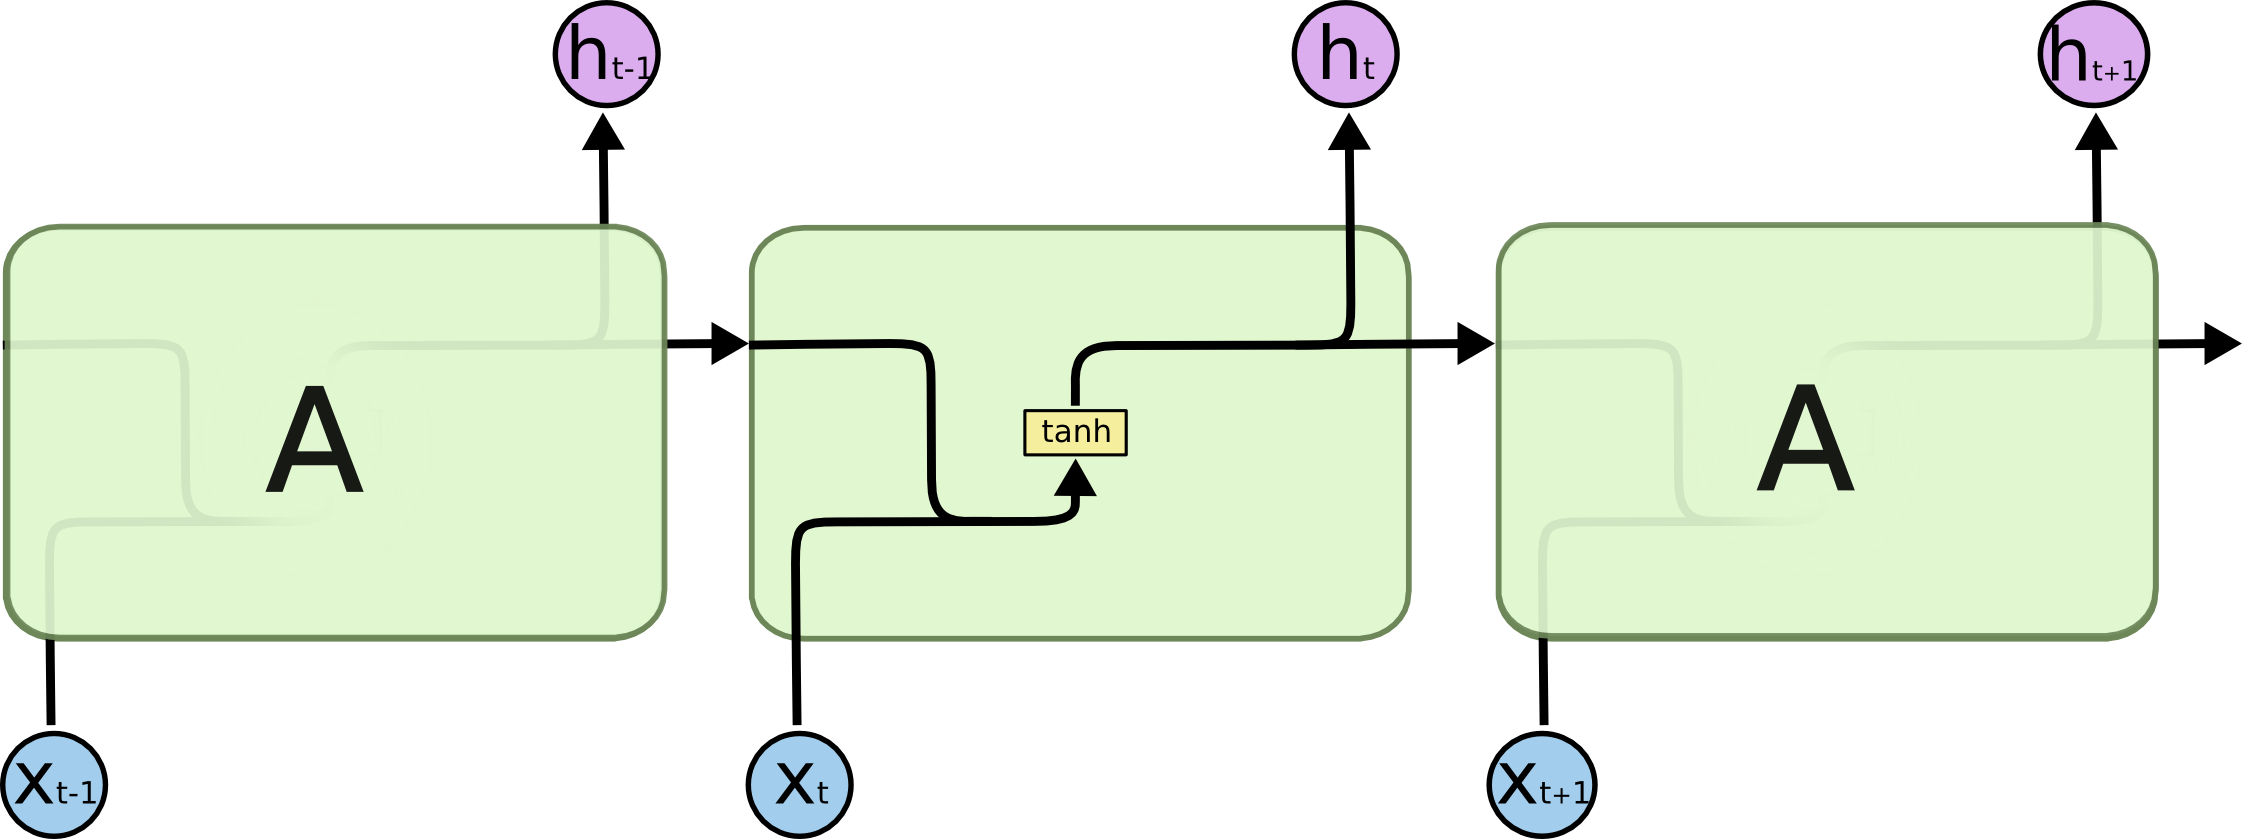

#### Three Key Properties of LSTM

1. **Explicit Memory: Cell State ($c_t$)**

   - LSTMs introduce a **cell state** $c_t$ that acts as an explicit memory.  
   - It is designed to allow information to flow along the sequence with minimal modifications, giving a **“highway” for gradient flow**.
   - This separates “memory storage” (cell state) from “output representation” (hidden state $h_t$).

2. **Gating Mechanisms**

   - LSTMs use **three gates** (all implemented with sigmoid+linear neurons):

     - **Forget gate** $f_t$: Controls how much of the **previous cell state** $c_{t-1}$ to keep or discard.  
     - **Input (update) gate** $i_t$: Controls how much **new information** to write into the cell state.  
     - **Output gate** $o_t$: Controls how much of the **cell state** to expose as hidden state $h_t$.

   - These gates are logistic-regression–like units that output values in $[0, 1]$ and are learned from data.

3. **Constant Error Carousel**

   - Because the cell state update is **additive** (not purely multiplicative), the gradient can flow backwards over many time steps without shrinking dramatically.
   - The direct connection $c_{t-1} \to c_t$ (modulated by the forget gate) provides a **smooth, largely unbroken path for gradients**, often described as the **constant error carousel**.
   - This structure is what allows LSTMs to preserve information across long sequences and mitigates vanishing/exploding gradients.

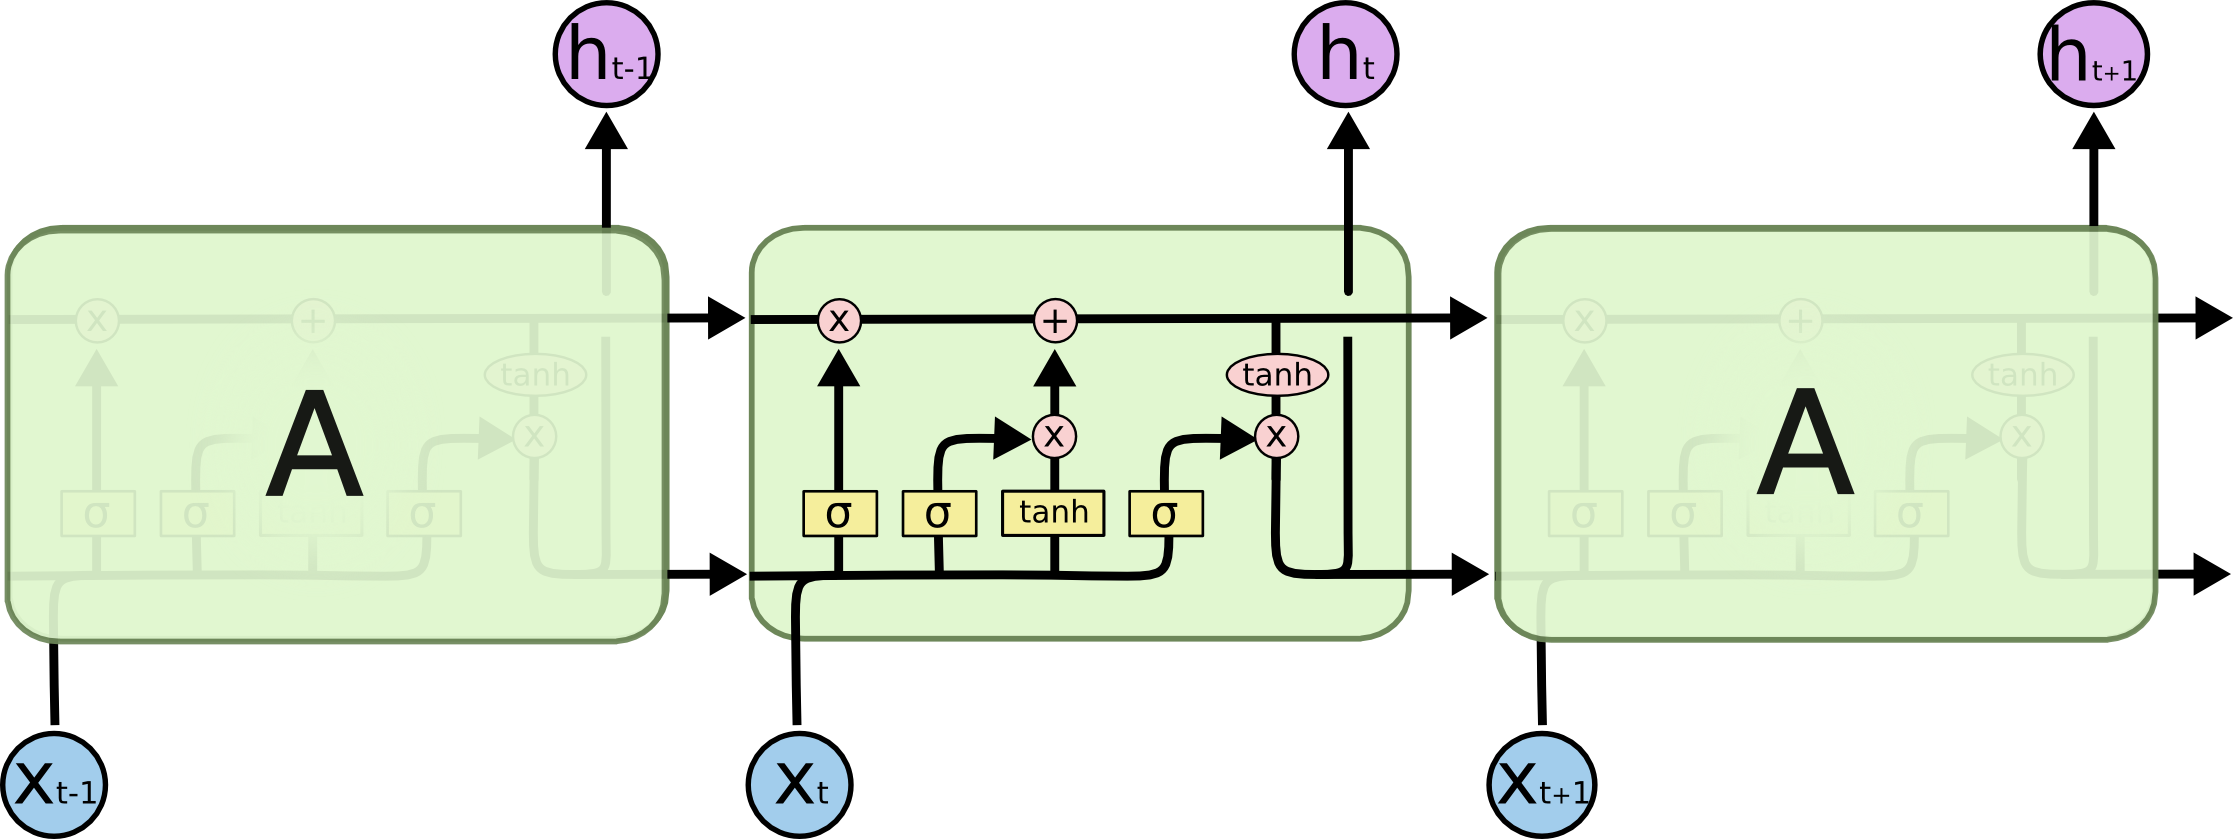

#### LSTM Cell Inputs and Outputs



For an LSTM cell at layer $l$ and time $t$:

**Inputs:**

- Previous hidden state: $h_{t-1}$ (vector).  
- Current input: $x_t$ (vector, e.g., word embedding).  
- Previous cell state: $c_{t-1}$ (vector).

**Outputs:**

- Current cell state: $c_t$ (updated memory).  
- Current hidden state: $h_t$ (output features, passed to next layer / next time step).

#### LSTM Feedforward Equations



Let $[h_{t-1}, x_t]$ be the concatenation of previous hidden state and current input.

1. **Gates and candidate:**

$$
\begin{aligned}
f_t &= \sigma(W_f [h_{t-1}, x_t] + b_f) \quad\text{(forget gate)} \\
i_t &= \sigma(W_i [h_{t-1}, x_t] + b_i) \quad\text{(input gate)} \\
\tilde{c}_t &= \tanh(W_c [h_{t-1}, x_t] + b_c) \quad\text{(candidate values)} \\
o_t &= \sigma(W_o [h_{t-1}, x_t] + b_o) \quad\text{(output gate)}
\end{aligned}
$$

2. **Cell state update and hidden state:**

$$
\begin{aligned}
c_t &= f_t \odot c_{t-1} + i_t \odot \tilde{c}_t \\
h_t &= o_t \odot \tanh(c_t)
\end{aligned}
$$

- $\odot$ is element-wise multiplication.
- Sigmoid gates $\sigma(\cdot)$ decide **how much** to keep/add/expose.
- $\tanh$ shapes new content and cell outputs to $[-1, 1]$.

#### Forget gate

- The **forget gate** decides how much of the previous cell state $c_{t-1}$ should be kept.  
- Its output $f_t$ comes from a sigmoid, so each component is between 0 and 1.  
- If $f_t = 0$ (for a component), that part of the old memory is **fully erased**; if $f_t = 1$, that part is **fully retained**.

Mathematically:
$$
c_t^{(\text{old part})} = f_t \odot c_{t-1}
$$
where $\odot$ is elementwise multiplication.

#### Candidate memory



- A **candidate memory** $\tilde{c}_t$ is computed from the current input $x_t$ and previous hidden state $h_{t-1}$ (typically via a $\tanh$ layer).  
- It represents **new information** that could be written into the cell state.

$$
\tilde{c}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)
$$

#### Input gate

- The **input gate** decides how much of this candidate memory $\tilde{c}_t$ should actually be written to the cell.  
- Its output $i_t$ (from a sigmoid) scales $\tilde{c}_t$: if a component of $i_t$ is large (near 1), that part of the new information is stored strongly; if it is small (near 0), that part is mostly ignored.

Cell state update combines forget and input gates:
$$
c_t = f_t \odot c_{t-1} + i_t \odot \tilde{c}_t
$$

#### Output gate

- The **output gate** controls how much of the (now updated) cell state $c_t$ is exposed as the next hidden state $h_t$.  
- Its sigmoid output $o_t$ gates the $\tanh(c_t)$: large values let more of the cell state be visible; small values hide it.

$$
h_t = o_t \odot \tanh(c_t)
$$

- **Forget gate**: “How much of the old memory should I keep?”  
- **Candidate memory**: “What new content could I add?”  
- **Input gate**: “How much of this new content should I actually write?”  
- **Output gate**: “How much of the current memory should I output as the hidden state?”  

Together, these gates let LSTMs **selectively remember, forget, and expose information**, which is why they handle long-term dependencies much better than simple RNNs.

**Parameter Count**

- A **vanilla RNN** layer has **1** set of recurrent+input weights.  
- An **LSTM** has **4** such sets: $W_f, W_i, W_c, W_o$ (each itself a concatenation of input and recurrent weights).  
- Thus, an LSTM layer has roughly **4×** the parameters of a comparable RNN layer.

**Consequences**

- **Higher computational cost** per time step.  
- **Higher risk of overfitting** if data is small.  
- In practice, sequence tasks (speech, translation, video) are complex enough that LSTMs’ extra capacity is beneficial and widely used.

- In most frameworks, you **primarily use $h_t$** as the layer output; the cell state $c_t$ is hidden internally or optionally exposed.  
- You can ask the LSTM to return:
  - Only the final hidden state (many-to-one tasks).  
  - Hidden states at all time steps (many-to-many tasks) using options like `return_sequences=True`.  
  - Optionally both hidden and cell states via `return_state=True`.

LSTMs are the standard choice when dealing with long sequences where vanilla RNNs fail due to vanishing gradients.

## Gated Recurrent Unit (GRU)

#### A Simpler Alternative to LSTM



While LSTMs solve vanishing gradients and handle long-term dependencies, they have:

- **4× parameter cost** vs simple RNN.  
- More complex cell structure.

To reduce complexity and training cost, researchers proposed the **Gated Recurrent Unit (GRU)** in 2014 as a **simplified, efficient alternative**:

- Similar effectiveness to LSTM in many tasks.  
- Fewer parameters (~**3×** RNN vs **4×** for LSTM).  
- Faster training and slightly less prone to overfitting on limited data.

Early results suggested GRUs and LSTMs were roughly comparable; later works often finds **LSTMs slightly superior**, but the definitive choice is problem-dependent and should be made **experimentally**.

#### Intuition

Key differences from LSTM:

- GRU has **no separate cell state**; it only keeps a **hidden state $h_t$**.  
- It uses **two gates**:
  - **Update gate** $z_t$  
  - **Reset gate** $r_t$

The GRU is designed so that $h_t$ becomes a **gated combination of the previous hidden state and a newly computed candidate**, allowing the network to explicitly control how much past information to carry forward.

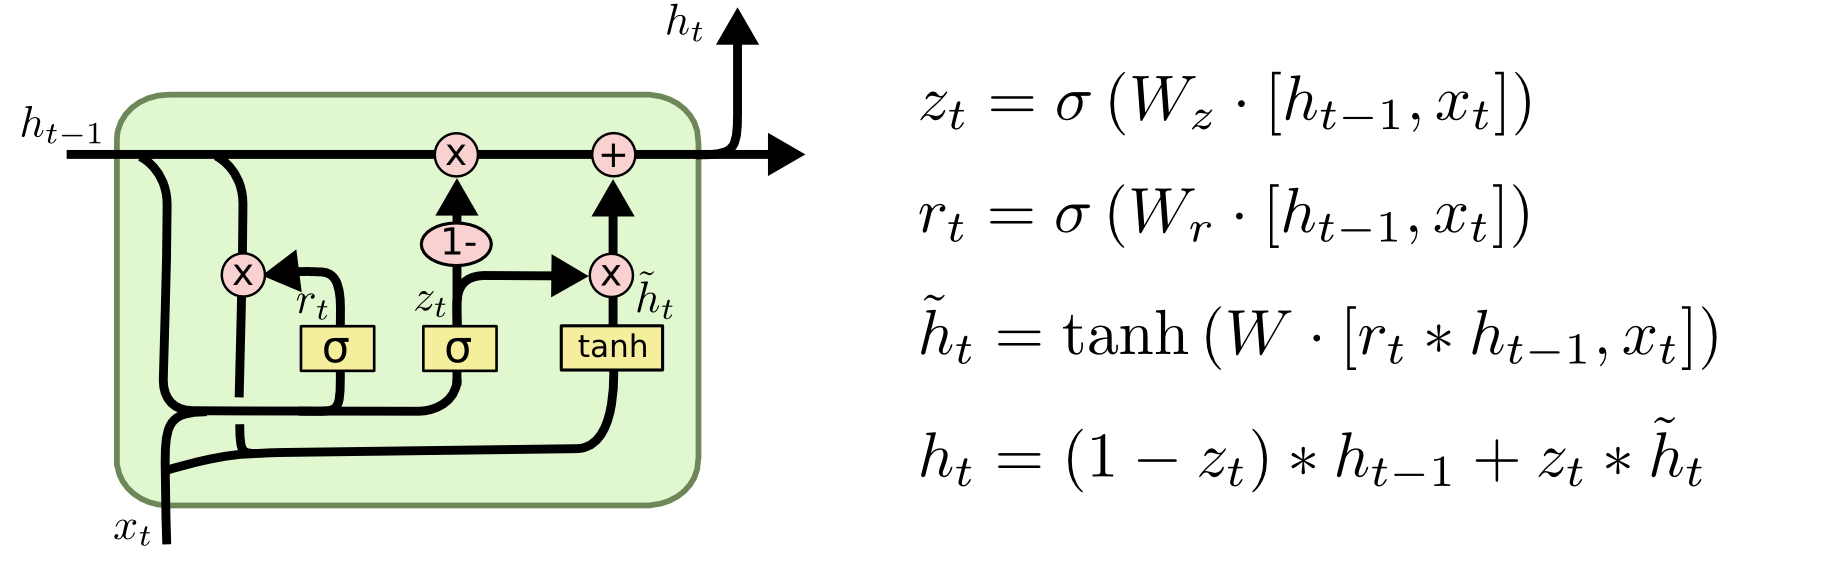

### GRU Feedforward Equations

Let $x_t$ be the input, $h_{t-1}$ the previous hidden state. Concatenated vector $[h_{t-1}, x_t]$ is used to compute gates.

1. **Gates:**

$$
\begin{aligned}
z_t &= \sigma(W_z [h_{t-1}, x_t] + b_z) \quad\text{(update gate)} \\
r_t &= \sigma(W_r [h_{t-1}, x_t] + b_r) \quad\text{(reset gate)}
\end{aligned}
$$

- $z_t$ decides **how much to keep from $h_{t-1}$ vs how much to overwrite** with $\tilde{h}_t$.  
- $r_t$ decides **how much of the previous hidden state should influence the candidate**.

2. **Candidate hidden state:**

$$
\tilde{h}_t = \tanh(W_h [\,r_t \odot h_{t-1}, x_t] + b_h)
$$

3. **Final hidden state (gated mixture):**

$$
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
$$

- **Update Gate $z_t$**  
  - If $z_t \approx 0$: keep mostly $h_{t-1}$ → **remember** past.  
  - If $z_t \approx 1$: take mostly $\tilde{h}_t$ → **update with new info**.

- **Reset Gate $r_t$**  
  - Applied before computing $\tilde{h}_t$.  
  - If $r_t \approx 0$: ignore previous state in the candidate → **reset part of memory**.  
  - If $r_t \approx 1$: use full $h_{t-1}$ in computing candidate.

The gates are sigmoids, so they output values in $[0, 1]$, and can be thought of as **soft selectors** controlling information flow.

#### GRU vs LSTM



**Commonalities:**

- Both address **vanishing gradients** and enable learning of long-term dependencies.  
- Both use **gating mechanisms** implemented as logistic-regression–style neurons.  
- Both produce a hidden state $h_t$ that can be used just like a vanilla RNN’s hidden state in higher layers.

**Differences:**

- LSTM:
  - Has separate **cell state $c_t$** + hidden state $h_t$.  
  - Uses three main gates (forget, input, output).  
  - More parameters (~4× RNN).  
  - Slightly more expressive and often slightly better in recent large-scale experiments.

- GRU:
  - No separate cell state; only **hidden state $h_t$**.  
  - Uses two gates (update, reset).  
  - Fewer parameters (~3× RNN).  
  - Often faster and simpler, especially for moderate-sized models.


- Use **LSTM** when maximizing performance on complex sequence tasks and you can afford the compute.  
- Use **GRU** when you want a **leaner model** with similar behavior and faster training.  
- **Experiment with both** on your problem and choose based on empirical performance rather than only theoretical arguments.


